In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
video_path = "../sample_data/LPW/LPW_1_1/VIDEOS/LPW_1_1_chunk_0.mp4"
annotation_path = video_path.replace("VIDEOS", "ANNOTATIONS").replace(".mp4", ".csv")
iris_mask_path = video_path.replace("VIDEOS", "IRIS")
subject_id = video_path.split("/")[-3]
chunk_id = os.path.basename(video_path).split(".")[0].split("_")[-1]

assert os.path.exists(video_path), f"Video path {video_path} does not exist!"
assert os.path.exists(annotation_path), f"Annotation path {annotation_path} does not exist!"
# assert os.path.exists(iris_mask_path), f"Iris mask path {iris_mask_path}"

In [3]:
def annotate_image(img, validity, gaze_vec, pupil_center, display_scale=3):
    img = img.copy()

    # resize before drawing text
    img = cv2.resize(
        img,
        None,
        fx=display_scale,
        fy=display_scale,
        interpolation=cv2.INTER_NEAREST
    )

    pupil_center = (
        int(pupil_center[0] * display_scale),
        int(pupil_center[1] * display_scale),
    )

    H, W = img.shape[:2]
    diag = np.sqrt(H * H + W * W)

    circle_radius = max(3, int(0.01 * diag))
    arrow_len = int(0.3 * min(H, W))
    thickness = max(2, int(0.004 * diag))
    font_scale = max(0.6, 0.003 * H)

    text_x = int(0.03 * W)
    text_y = int(0.1 * H)
    
    is_valid = validity == 1
    color = (0, 255, 0) if is_valid else (0, 0, 255)

    cv2.putText(
        img,
        f"Validity: {'Valid' if is_valid else 'Invalid'}",
        (text_x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        color,
        thickness,
        cv2.LINE_AA
    )

    cx, cy = pupil_center
    cv2.circle(img, (cx, cy), circle_radius, (255, 0, 0), -1)

    gx, gy, gz = gaze_vec
    yaw = np.arctan2(gx, gz)
    pitch = np.arctan2(gy, gz)

    dx = int(np.sin(yaw) * np.cos(pitch) * arrow_len)
    dy = int(np.sin(pitch) * arrow_len)

    cv2.arrowedLine(
        img,
        (cx, cy),
        (cx + dx, cy + dy),
        (0, 255, 255),
        thickness,
        cv2.LINE_AA,
        tipLength=0.2
    )

    return img

In [4]:
cap = cv2.VideoCapture(video_path)
if os.path.exists(iris_mask_path):
    contains_iris_mask = True
    iris_cap = cv2.VideoCapture(iris_mask_path)
    iris_masks = []
else:
    contains_iris_mask = False
images = []
while True:
    ret, frame = cap.read()
    if contains_iris_mask:
        ret_iris, iris_mask = iris_cap.read()
    if not ret:
        break
    images.append(frame)
    if contains_iris_mask:
        iris_masks.append(iris_mask)
cap.release()
images = np.array(images)
if contains_iris_mask:
    iris_cap.release()
    iris_masks = np.array(iris_masks)

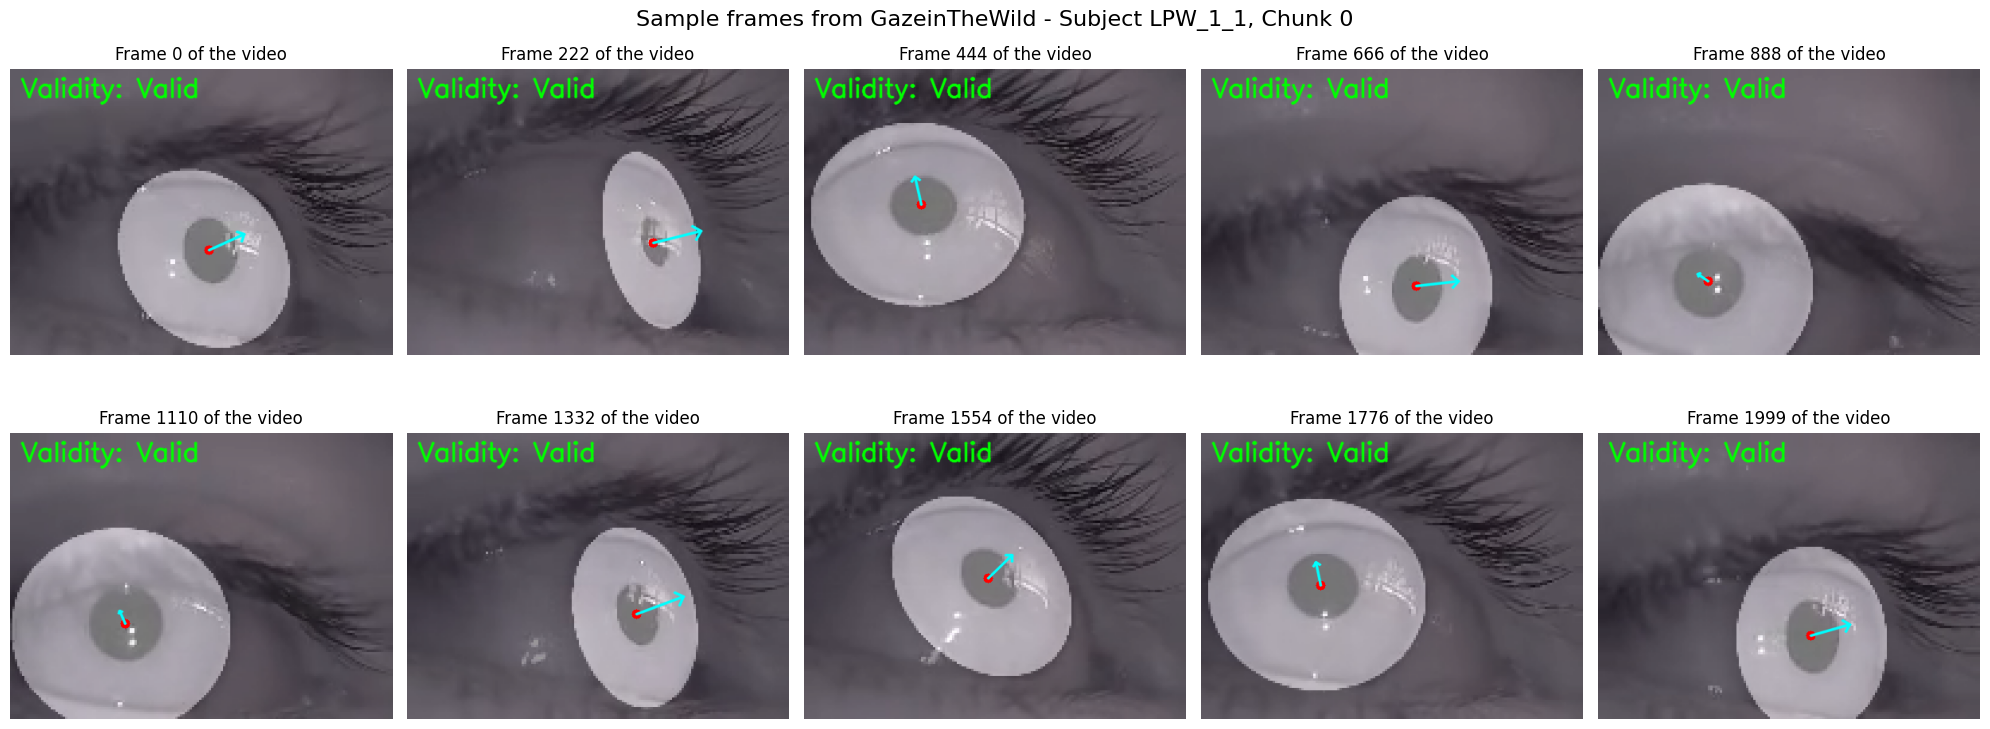

In [5]:
annotation_df = pd.read_csv(annotation_path)
fig, ax = plt.subplots(2, 5, figsize=(20, 8))

num_show_images = 10
image_indices = np.linspace(0, len(images) - 1, num_show_images, dtype=int)

alpha = 0.6  # weight of img1
beta = 0.4   # weight of img2
for idx, i in enumerate(image_indices):
    img = images[i]
    if contains_iris_mask:
        iris_mask = iris_masks[i]
        overlay = cv2.addWeighted(img, alpha, iris_mask, beta, 0)
    else:
        overlay = img
    img = annotate_image(
        overlay,
        validity=annotation_df.loc[i, "validity"],
        gaze_vec=annotation_df.loc[i, ["gaze_x", "gaze_y", "gaze_z"]].values,
        pupil_center=annotation_df.loc[i, ["pupil_center_x", "pupil_center_y"]].values
    )
    ax[idx // 5, idx % 5].imshow(img)
    ax[idx // 5, idx % 5].set_title(f"Frame {i} of the video")
    ax[idx // 5, idx % 5].axis("off")
plt.tight_layout()
plt.suptitle(f"Sample frames from GazeinTheWild - Subject {subject_id}, Chunk {chunk_id}", fontsize=16)
plt.show()